Importing necessary packges

In [286]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')
import folium
from folium.plugins import HeatMap
from geopy.geocoders import Nominatim
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from flask import Flask, request, jsonify
import joblib
from yellowbrick.model_selection import RFECV

In [287]:
#get all sheet_names in an excel
pd.ExcelFile("Challenge dataset.xlsx").sheet_names

['2019 ', '2020 ', 'Volontaire']

Reading of the data

In [288]:
candidate_donor=pd.read_excel("Challenge dataset.xlsx",sheet_name='2019 ')
candidate_donor.head(2)

,Date de remplissage de la fiche,Date de naissance,Niveau d'etude,Genre,Taille,Poids,Situation Matrimoniale (SM),Profession,Arrondissement de résidence,Quartier de Résidence,...,"Raison de non-eligibilité totale [Porteur(HIV,hbs,hcv)]",Raison de non-eligibilité totale [Opéré],Raison de non-eligibilité totale [Drepanocytaire],Raison de non-eligibilité totale [Diabétique],Raison de non-eligibilité totale [Hypertendus],Raison de non-eligibilité totale [Asthmatiques],Raison de non-eligibilité totale [Cardiaque],Raison de non-eligibilité totale [Tatoué],Raison de non-eligibilité totale [Scarifié],Si autres raison préciser
0,3/11/0019,1999-09-01 00:00:00,Pas Précisé,Homme,NaN,NaN,Célibataire,Chaudronnier,Douala 3,Logbaba,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3/21/0019,1978-02-04 00:00:00,Universitaire,Homme,NaN,NaN,Marié (e),Secrétaire comptable,Douala (Non précisé ),NDOGPASSI 2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Renamig the columns into understable names

Date de remplissage de la fiche: Date of donor registration form
○ Date de naissance: The birthdate of the individual
○ Niveau d'etude: The educational level
○ Genre: Gender
○ Taille: Height of the individual
○ Poids: Weight of the individual
○ Situation Matrimoniale (SM): Marital status
○ Profession: The profession
Raison de non-eligibilité totale: Reasons why a donor is not eligible for
donation.
○ [Porteur(HIV,hbs,hcv)]: Indicates whether the donor is a carrier of any
blood-borne infections
○ [Opéré]: Indicates whether the donor has undergone any surgeries.
○ [Drepanocytaire]: Indicates whether the donor has sickle cell disease
(Drepanocytosis).
○ [Diabétique]: Indicates whether the donor is diabetic.
○ [Hypertendus]: Indicates whether the donor has hypertension.
○ [Asthmatiques]: Indicates whether the donor has asthma.
○ [Cardiaque]: Indicates whether the donor has any heart-related conditions.
○ [Tatoué]: Indicates whether the donor has tattoos.
○ [Scarifié]: Indicates whether the donor has scars
Arrondissement de résidence: The district or area where the donor resides

○ Quartier de Résidence: The specific neighborhood or residential area of


In [289]:
#renaming the column names
candidate_donor.rename(columns={
    'Date de remplissage de la fiche':'Date of Donor Registation',
    'Date de naissance':'Date of Birth',
    "Niveau d'etude":'Education Level',
    'Genre':'Gender',
    'Taille':'Height',
    'Poids':'Weight',
    'Situation Matrimoniale (SM)':'Marital Status',
    'Profession':'Profession',
    'Arrondissement de résidence':'Area of residence',
    'Quartier de Résidence':'Neighborhood of residence',
    'Nationalité':'Nationality',
    'Langue maternelle':'Mother Tongue',
    'Religion':'Religion',
    'A-t-il (elle) déjà donné le sang':'Have you donated blood before?',
    'Si oui preciser la date du dernier don.':'Date of last donation',
    'Taux d’hémoglobine':'Hemoglobin',
    'Raison de non-eligibilité totale':'Reason for non-eligibility',
    'Raison de non-eligibilité totale  [Porteur(HIV,hbs,hcv)]':'Porteur(HIV,hbs,hcv)',
    'Raison de non-eligibilité totale  [Opéré]':'Operated',
    'Raison de non-eligibilité totale  [Drepanocytaire]':'Drepanocytaire',
    'Raison de non-eligibilité totale  [Diabétique]':'Diabetic',
    'Raison de non-eligibilité totale  [Hypertendus]':'Hypertensive',
    'Raison de non-eligibilité totale  [Asthmatiques]':'Asthmatic',
    'Raison de non-eligibilité totale  [Cardiaque]':'Cardiac',
    'Raison de non-eligibilité totale  [Tatoué]':'Tattooed',
    'Raison de non-eligibilité totale  [Scarifié]':'Scarred',
    'Si autres raison préciser':'Other reason'
},inplace=True)
candidate_donor.rename(columns={'ÉLIGIBILITÉ AU DON.':'Eligibility To Donate'},inplace=True)
candidate_donor.rename(columns={
    'Raison indisponibilité  [Est sous anti-biothérapie  ]': 'Unavailable_Antibiotherapy',
    'Raison indisponibilité  [Taux d’hémoglobine bas ]': 'Unavailable_Low_Hemoglobin',
    'Raison indisponibilité  [date de dernier Don < 3 mois ]': 'Unavailable_Recent_Donation',
    'Raison indisponibilité  [IST récente (Exclu VIH, Hbs, Hcv)]': 'Unavailable_Recent_IST',
    'Date de dernières règles (DDR) ': 'Last_Menstrual_Period',
    'Raison de l’indisponibilité de la femme [La DDR est mauvais si <14 jour avant le don]': 'Unavailable_Bad_DDR',
    'Raison de non-eligibilité totale  [Antécédent de transfusion]': 'Transfused less than 3 months ago',
    'Raison de l’indisponibilité de la femme [Allaitement ]': 'Unavailable_Breastfeeding',
    'Raison de l’indisponibilité de la femme [A accoucher ces 6 derniers mois  ]': 'Unavailable_Recent_Childbirth',
    'Raison de l’indisponibilité de la femme [Interruption de grossesse  ces 06 derniers mois]': 'Unavailable_Recent_Miscarriage',
    'Raison de l’indisponibilité de la femme [est enceinte ]': 'Unavailable_Pregnant',
    'Autre raisons,  preciser': 'Other_Reasons',
    'Sélectionner "ok" pour envoyer': 'Confirm_Submission'
}, inplace=True)

In [290]:
display(candidate_donor.head(2))

,Date of Donor Registation,Date of Birth,Education Level,Gender,Height,Weight,Marital Status,Profession,Area of residence,Neighborhood of residence,...,"Porteur(HIV,hbs,hcv)",Operated,Drepanocytaire,Diabetic,Hypertensive,Asthmatic,Cardiac,Tattooed,Scarred,Other reason
0,3/11/0019,1999-09-01 00:00:00,Pas Précisé,Homme,NaN,NaN,Célibataire,Chaudronnier,Douala 3,Logbaba,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3/21/0019,1978-02-04 00:00:00,Universitaire,Homme,NaN,NaN,Marié (e),Secrétaire comptable,Douala (Non précisé ),NDOGPASSI 2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [291]:
display(candidate_donor.columns)

Index(['Date of Donor Registation', 'Date of Birth', 'Education Level',
       'Gender', 'Height', 'Weight', 'Marital Status', 'Profession',
       'Area of residence', 'Neighborhood of residence', 'Nationality',
       'Religion', 'Have you donated blood before?', 'Date of last donation',
       'Hemoglobin', 'Eligibility To Donate', 'Unavailable_Antibiotherapy',
       'Unavailable_Low_Hemoglobin', 'Unavailable_Recent_Donation',
       'Unavailable_Recent_IST', 'Last_Menstrual_Period',
       'Unavailable_Bad_DDR', 'Unavailable_Breastfeeding',
       'Unavailable_Recent_Childbirth', 'Unavailable_Recent_Miscarriage',
       'Unavailable_Pregnant', 'Other_Reasons', 'Confirm_Submission',
       'Transfused less than 3 months ago', 'Porteur(HIV,hbs,hcv)', 'Operated',
       'Drepanocytaire', 'Diabetic', 'Hypertensive', 'Asthmatic', 'Cardiac',
       'Tattooed', 'Scarred', 'Other reason'],
      dtype='object')

Investigate if duplicates

In [292]:
candidate_donor.shape

(1915, 39)

Classifying the data into demographic and health data

In [293]:
candidate_donor.columns = candidate_donor.columns.str.strip()

# Define health-related columns for grouping
health_columns = [
    'Unavailable_Antibiotherapy', 'Unavailable_Low_Hemoglobin', 'Unavailable_Recent_Donation',
    'Unavailable_Recent_IST', 'Last_Menstrual_Period', 'Unavailable_Bad_DDR',
    'Unavailable_Breastfeeding', 'Unavailable_Recent_Childbirth', 'Unavailable_Recent_Miscarriage',
    'Unavailable_Pregnant', 'Other_Reasons', 'Confirm_Submission',
    'Transfused less than 3 months ago',
    'Porteur(HIV,hbs,hcv)', 'Operated', 'Drepanocytaire', 'Diabetic',
    'Hypertensive', 'Asthmatic', 'Cardiac', 'Tattooed', 'Scarred', 'Other reason'
]
demographic_colmns=['Date of Donor Registation','Date of Birth','Education Level','Gender','Height','Weight','Marital Status','Profession','Area of residence','Neighborhood of residence','Nationality']

Data Exploration for outlier and missing values

Geographical location of donors

In [294]:
display(candidate_donor.dtypes)

Date of Donor Registation                    object
Date of Birth                                object
Education Level                              object
Gender                                       object
Height                                      float64
Weight                                      float64
Marital Status                               object
Profession                                   object
Area of residence                            object
Neighborhood of residence                    object
Nationality                                  object
Religion                                     object
Have you donated blood before?               object
Date of last donation                        object
Hemoglobin                                   object
Eligibility To Donate                        object
Unavailable_Antibiotherapy                   object
Unavailable_Low_Hemoglobin                   object
Unavailable_Recent_Donation                  object
Unavailable_

In [295]:
display(candidate_donor.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915 entries, 0 to 1914
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date of Donor Registation          1913 non-null   object        
 1   Date of Birth                      1915 non-null   object        
 2   Education Level                    1915 non-null   object        
 3   Gender                             1915 non-null   object        
 4   Height                             62 non-null     float64       
 5   Weight                             106 non-null    float64       
 6   Marital Status                     1915 non-null   object        
 7   Profession                         1915 non-null   object        
 8   Area of residence                  1915 non-null   object        
 9   Neighborhood of residence          1915 non-null   object        
 10  Nationality                        1

None

In [296]:
candidate_donor.describe()

,Height,Weight,Last_Menstrual_Period
count,62.000000,106.000000,40
mean,172.596774,77.481132,2019-07-24 19:12:00
min,158.000000,55.000000,2019-01-25 00:00:00
25%,168.000000,69.250000,2019-05-22 12:00:00
50%,172.000000,75.000000,2019-07-24 12:00:00
75%,177.000000,85.000000,2019-10-07 00:00:00
max,192.000000,120.000000,2019-11-09 00:00:00
std,7.023286,12.467276,NaN


In [297]:
candidate_donor.isnull().sum()

Date of Donor Registation               2
Date of Birth                           0
Education Level                         0
Gender                                  0
Height                               1853
Weight                               1809
Marital Status                          0
Profession                              0
Area of residence                       0
Neighborhood of residence               0
Nationality                             0
Religion                                0
Have you donated blood before?          0
Date of last donation                1117
Hemoglobin                            845
Eligibility To Donate                   0
Unavailable_Antibiotherapy           1748
Unavailable_Low_Hemoglobin           1716
Unavailable_Recent_Donation          1755
Unavailable_Recent_IST               1757
Last_Menstrual_Period                1875
Unavailable_Bad_DDR                  1856
Unavailable_Breastfeeding            1856
Unavailable_Recent_Childbirth     

Handling missing values

In [298]:
#uniuqe entries in the health_columns
for col in health_columns:
    print(f"Unique entries in {col}:")
    print(candidate_donor[col].unique())
    print("\n")

Unique entries in Unavailable_Antibiotherapy:
[nan 'Non' 'Oui']


Unique entries in Unavailable_Low_Hemoglobin:
[nan 'Oui' 'Non']


Unique entries in Unavailable_Recent_Donation:
[nan 'Non' 'Oui']


Unique entries in Unavailable_Recent_IST:
[nan 'Non' 'Oui']


Unique entries in Last_Menstrual_Period:
<DatetimeArray>
[                'NaT', '2019-10-06 00:00:00', '2019-09-26 00:00:00',
 '2019-10-29 00:00:00', '2019-10-15 00:00:00', '2019-10-17 00:00:00',
 '2019-10-24 00:00:00', '2019-10-25 00:00:00', '2019-11-09 00:00:00',
 '2019-11-01 00:00:00', '2019-10-31 00:00:00', '2019-09-23 00:00:00',
 '2019-09-10 00:00:00', '2019-06-05 00:00:00', '2019-06-01 00:00:00',
 '2019-06-03 00:00:00', '2019-06-02 00:00:00', '2019-06-06 00:00:00',
 '2019-05-05 00:00:00', '2019-05-17 00:00:00', '2019-05-18 00:00:00',
 '2019-05-08 00:00:00', '2019-05-23 00:00:00', '2019-04-11 00:00:00',
 '2019-04-26 00:00:00', '2019-03-22 00:00:00', '2019-07-23 00:00:00',
 '2019-08-17 00:00:00', '2019-07-26 00:00:00', '2019

In [299]:
#replace the 'Oui' and 'Non' with 'Yes' and 'No'-health columns
candidate_donor['Scarred'] = candidate_donor['Scarred'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Tattooed'] = candidate_donor['Tattooed'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Cardiac'] = candidate_donor['Cardiac'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Asthmatic'] = candidate_donor['Asthmatic'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Hypertensive'] = candidate_donor['Hypertensive'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Diabetic'] = candidate_donor['Diabetic'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Drepanocytaire'] = candidate_donor['Drepanocytaire'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Operated'] = candidate_donor['Operated'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Porteur(HIV,hbs,hcv)'] = candidate_donor['Porteur(HIV,hbs,hcv)'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Transfused less than 3 months ago'] = candidate_donor['Transfused less than 3 months ago'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Unavailable_Pregnant'] = candidate_donor['Unavailable_Pregnant'].replace({'Non': 'No', np.nan: 'No'}).fillna('No')
candidate_donor['Unavailable_Recent_Miscarriage'] = candidate_donor['Unavailable_Recent_Miscarriage'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Unavailable_Recent_Childbirth'] = candidate_donor['Unavailable_Recent_Childbirth'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Unavailable_Breastfeeding'] = candidate_donor['Unavailable_Breastfeeding'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Unavailable_Bad_DDR'] = candidate_donor['Unavailable_Bad_DDR'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Unavailable_Recent_IST'] = candidate_donor['Unavailable_Recent_IST'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Unavailable_Recent_Donation'] = candidate_donor['Unavailable_Recent_Donation'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Unavailable_Low_Hemoglobin'] = candidate_donor['Unavailable_Low_Hemoglobin'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Unavailable_Antibiotherapy'] = candidate_donor['Unavailable_Antibiotherapy'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Date of last donation'] = candidate_donor['Date of last donation'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Have you donated blood before?'] = candidate_donor['Have you donated blood before?'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Confirm_Submission'] = candidate_donor['Confirm_Submission'].replace({'Ok': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Other reason'] = candidate_donor['Other_Reasons'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')
candidate_donor['Other_Reasons'] = candidate_donor['Other_Reasons'].replace({'Oui': 'Yes', np.nan: 'No'}).fillna('No')


In [300]:
candidate_donor.isnull().sum()

Date of Donor Registation               2
Date of Birth                           0
Education Level                         0
Gender                                  0
Height                               1853
Weight                               1809
Marital Status                          0
Profession                              0
Area of residence                       0
Neighborhood of residence               0
Nationality                             0
Religion                                0
Have you donated blood before?          0
Date of last donation                   0
Hemoglobin                            845
Eligibility To Donate                   0
Unavailable_Antibiotherapy              0
Unavailable_Low_Hemoglobin              0
Unavailable_Recent_Donation             0
Unavailable_Recent_IST                  0
Last_Menstrual_Period                1875
Unavailable_Bad_DDR                     0
Unavailable_Breastfeeding               0
Unavailable_Recent_Childbirth     

In [301]:
#Date of donor registration- fill with the most date or registration
candidate_donor["Date of Donor Registation"] = pd.to_datetime(candidate_donor["Date of Donor Registation"], errors='coerce')
candidate_donor.fillna(candidate_donor["Date of Donor Registation"].mode().iloc[0], inplace=True)

In [302]:
#Date of Birth- fill with the most date or registration
candidate_donor["Date of Birth"] = pd.to_datetime(candidate_donor["Date of Birth"], errors='coerce')
candidate_donor.fillna(candidate_donor["Date of Birth"].mode().iloc[0], inplace=True)


In [303]:
#Hemoglobin
#omit g/dl and replace , with .
candidate_donor["Hemoglobin"] = candidate_donor["Hemoglobin"].astype(str).str.replace('g/dl', '').str.replace(',', '.')
candidate_donor["Hemoglobin"] = pd.to_numeric(candidate_donor["Hemoglobin"], errors='coerce')
candidate_donor["Hemoglobin"].fillna(candidate_donor["Hemoglobin"].median(), inplace=True)

In [304]:
# Handling Height & Weight
#transform to float
candidate_donor["Height"] = pd.to_numeric(candidate_donor["Height"], errors='coerce')
candidate_donor["Weight"] = pd.to_numeric(candidate_donor["Weight"], errors='coerce')

candidate_donor["Height"] = candidate_donor["Height"].astype(float)
candidate_donor["Weight"] = candidate_donor["Weight"].astype(float)
num_imputer = SimpleImputer(strategy='median')
candidate_donor["Height"] = num_imputer.fit_transform(candidate_donor[["Height"]])
candidate_donor["Weight"] = num_imputer.fit_transform(candidate_donor[["Weight"]])

In [305]:
candidate_donor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1915 entries, 0 to 1914
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date of Donor Registation          1915 non-null   datetime64[ns]
 1   Date of Birth                      1915 non-null   datetime64[ns]
 2   Education Level                    1915 non-null   object        
 3   Gender                             1915 non-null   object        
 4   Height                             1915 non-null   float64       
 5   Weight                             1915 non-null   float64       
 6   Marital Status                     1915 non-null   object        
 7   Profession                         1915 non-null   object        
 8   Area of residence                  1915 non-null   object        
 9   Neighborhood of residence          1915 non-null   object        
 10  Nationality                        1

In [306]:
candidate_donor.head(2)

,Date of Donor Registation,Date of Birth,Education Level,Gender,Height,Weight,Marital Status,Profession,Area of residence,Neighborhood of residence,...,"Porteur(HIV,hbs,hcv)",Operated,Drepanocytaire,Diabetic,Hypertensive,Asthmatic,Cardiac,Tattooed,Scarred,Other reason
0,2019-08-06,1999-09-01,Pas Précisé,Homme,172.0,75.0,Célibataire,Chaudronnier,Douala 3,Logbaba,...,No,No,No,No,No,No,No,No,No,No
1,2019-08-06,1978-02-04,Universitaire,Homme,172.0,75.0,Marié (e),Secrétaire comptable,Douala (Non précisé ),NDOGPASSI 2,...,No,No,No,No,No,No,No,No,No,No


Visualize the geographical distribution of blood donors based on their residential area

In [307]:
area_resd=candidate_donor['Area of residence'].unique()
area_resd

array(['Douala 3', 'Douala (Non précisé )', 'Douala 5', 'Douala 1',
       'Yaounde', 'Douala 2', 'Douala 4', 'Bafoussam', 'Dschang',
       'Non précisé', 'Buea', 'Kribi', 'Pas précisé', 'Njombe', 'TIKO',
       'Edea', 'Manjo', 'West', 'Douala', 'Yaoundé', 'OYACK', 'Nkouabang',
       'BUEA', 'Deido', 'Pas mentionné', 'Douala 6', 'batie',
       'Bomono Ba Mbegue', 'Meiganga', 'Pas precise', 'non precisé',
       'SUD OUEST TOMBEL', 'Pas précisé ', 'Ngodi Bakoko ', 'Ras',
       'R A S ', 'LIMBE ', 'R A S', 'RAS', 'DCANKONGMONDO', 'BOKO',
       'RAS '], dtype=object)

In [308]:
candidate_donor['Area of residence'] = candidate_donor['Area of residence'].str.strip().str.upper().str.replace(' ', ' ')

In [309]:
area_resd=candidate_donor['Area of residence'].unique()
area_resd

array(['DOUALA 3', 'DOUALA (NON PRÉCISÉ )', 'DOUALA 5', 'DOUALA 1',
       'YAOUNDE', 'DOUALA 2', 'DOUALA 4', 'BAFOUSSAM', 'DSCHANG',
       'NON PRÉCISÉ', 'BUEA', 'KRIBI', 'PAS PRÉCISÉ', 'NJOMBE', 'TIKO',
       'EDEA', 'MANJO', 'WEST', 'DOUALA', 'YAOUNDÉ', 'OYACK', 'NKOUABANG',
       'DEIDO', 'PAS MENTIONNÉ', 'DOUALA 6', 'BATIE', 'BOMONO BA MBEGUE',
       'MEIGANGA', 'PAS PRECISE', 'NON PRECISÉ', 'SUD OUEST TOMBEL',
       'NGODI BAKOKO', 'RAS', 'R A S', 'LIMBE', 'DCANKONGMONDO', 'BOKO'],
      dtype=object)

In [310]:
candidate_donor['Area of residence'].replace('R A S', 'RAS', inplace=True)
candidate_donor['Area of residence'].replace('DOUALA (NON PRÉCISÉ )','NON PRECISÉ', inplace=True)
candidate_donor['Area of residence'].replace('NON PRÉCISÉ','NON PRECISÉ', inplace=True)
candidate_donor['Area of residence'].replace('PAS PRECISE','PAS PRÉCISÉ', inplace=True)
candidate_donor['Area of residence'].replace('DOUALA 3','DOUALA', inplace=True)
candidate_donor['Area of residence'].replace('DOUALA 2','DOUALA', inplace=True)
candidate_donor['Area of residence'].replace('DOUALA 1','DOUALA', inplace=True)
candidate_donor['Area of residence'].replace('DOUALA 4','DOUALA', inplace=True)
candidate_donor['Area of residence'].replace('DOUALA 5','DOUALA', inplace=True)



In [311]:
area_resd=candidate_donor['Area of residence'].unique()
area_resd

array(['DOUALA', 'NON PRECISÉ', 'YAOUNDE', 'BAFOUSSAM', 'DSCHANG', 'BUEA',
       'KRIBI', 'PAS PRÉCISÉ', 'NJOMBE', 'TIKO', 'EDEA', 'MANJO', 'WEST',
       'YAOUNDÉ', 'OYACK', 'NKOUABANG', 'DEIDO', 'PAS MENTIONNÉ',
       'DOUALA 6', 'BATIE', 'BOMONO BA MBEGUE', 'MEIGANGA',
       'SUD OUEST TOMBEL', 'NGODI BAKOKO', 'RAS', 'LIMBE',
       'DCANKONGMONDO', 'BOKO'], dtype=object)

Cleaning Nationality

In [312]:
location_count = candidate_donor.groupby('Area of residence').size()
location_count.sort_values(ascending=False,inplace=True)
location_count=pd.DataFrame(location_count)
location_count.rename(columns={0:'Count'},inplace=True)
location_count

,Count
Area of residence,
NON PRECISÉ,991
DOUALA,845
RAS,17
YAOUNDE,14
EDEA,11
PAS PRÉCISÉ,9
BUEA,3
DOUALA 6,3
KRIBI,2


In [313]:
location_coordinates = [
    {"CITY": "FOUMBAN", "LATITUDE": "5.727662", "LONGITUDE": "10.885811"},
    {"CITY": "KOUSSERI", "LATITUDE": "12.084255", "LONGITUDE": "15.017879"},
    {"CITY": "YAOUNDE", "LATITUDE": "3.844119", "LONGITUDE": "11.501346"},
    {"CITY": "EDEA", "LATITUDE": "3.794647", "LONGITUDE": "10.132141"},
    {"CITY": "MAROUA", "LATITUDE": "10.592529", "LONGITUDE": "14.321009"},
    {"CITY": "DOUALA", "LATITUDE": "4.061536", "LONGITUDE": "9.786072"},
    {"CITY": "BUEA", "LATITUDE": "4.159302", "LONGITUDE": "9.243536"}
]


In [314]:
#mao the location_data
m = folium.Map(location=[4.061536, 9.786072], zoom_start=6)
#add the values in location_data

for location in location_coordinates:
    folium.Marker(
        location=[location["LATITUDE"], location["LONGITUDE"]],
        popup=location["CITY"],
        icon=folium.Icon(color="green"),
    ).add_to(m)

m

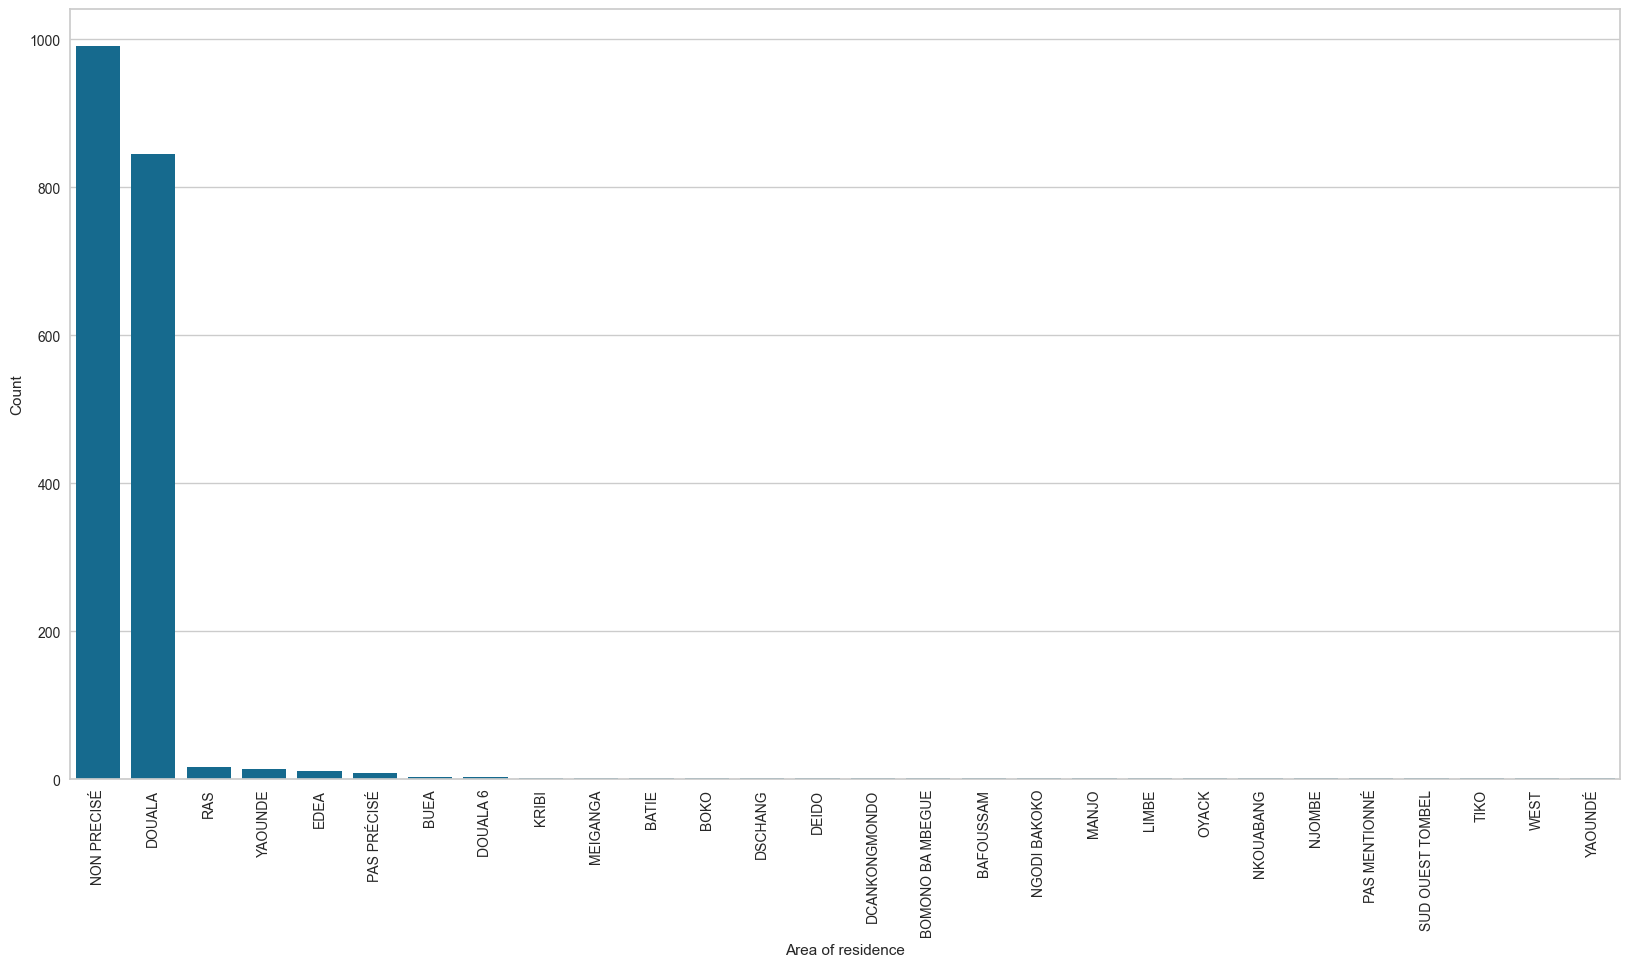

In [315]:
#graph
plt.figure(figsize=(20,10))
sns.barplot(x='Area of residence',y='Count',data=location_count)
plt.xticks(rotation=90)
plt.show()

Nationality

In [316]:
nationality=candidate_donor['Nationality'].unique()
nationality

array(['Camerounaise', 'Malienne', 'Centrafricaine', 'Non precisé',
       'Rien', 'AMERICAINE', 'Malien', 'Tchadienne', 'R.A.S', 'R A S',
       'RAS', 'R A S ', 'Ras', ' R A S', 'CENTRAFRICAINE'], dtype=object)

In [317]:
candidate_donor['Nationality'] = candidate_donor['Nationality'].str.strip().str.upper().str.replace(' ', ' ')

In [318]:
candidate_donor['Nationality'].replace('R A S', 'RAS', inplace=True)
candidate_donor['Nationality'].replace('R.A.S','RAS', inplace=True)


In [319]:
nationality=candidate_donor['Nationality'].unique()
nationality

array(['CAMEROUNAISE', 'MALIENNE', 'CENTRAFRICAINE', 'NON PRECISÉ',
       'RIEN', 'AMERICAINE', 'MALIEN', 'TCHADIENNE', 'RAS'], dtype=object)

Eligibility to Donate

In [320]:
candidate_donor.columns

Index(['Date of Donor Registation', 'Date of Birth', 'Education Level',
       'Gender', 'Height', 'Weight', 'Marital Status', 'Profession',
       'Area of residence', 'Neighborhood of residence', 'Nationality',
       'Religion', 'Have you donated blood before?', 'Date of last donation',
       'Hemoglobin', 'Eligibility To Donate', 'Unavailable_Antibiotherapy',
       'Unavailable_Low_Hemoglobin', 'Unavailable_Recent_Donation',
       'Unavailable_Recent_IST', 'Last_Menstrual_Period',
       'Unavailable_Bad_DDR', 'Unavailable_Breastfeeding',
       'Unavailable_Recent_Childbirth', 'Unavailable_Recent_Miscarriage',
       'Unavailable_Pregnant', 'Other_Reasons', 'Confirm_Submission',
       'Transfused less than 3 months ago', 'Porteur(HIV,hbs,hcv)', 'Operated',
       'Drepanocytaire', 'Diabetic', 'Hypertensive', 'Asthmatic', 'Cardiac',
       'Tattooed', 'Scarred', 'Other reason'],
      dtype='object')

In [321]:
shared_health_columns=['Porteur(HIV,hbs,hcv)', 'Operated',
       'Drepanocytaire', 'Diabetic', 'Hypertensive', 'Asthmatic', 'Cardiac',
       'Tattooed', 'Scarred']
not_eligible=candidate_donor[(candidate_donor['Eligibility To Donate'] != 'Eligible')]
not_eligible.shape



(313, 39)

Porteur(HIV,hbs,hcv)     6
Operated                37
Drepanocytaire           2
Diabetic                 2
Hypertensive             1
Asthmatic                2
Cardiac                 12
Tattooed                14
Scarred                 14
dtype: int64

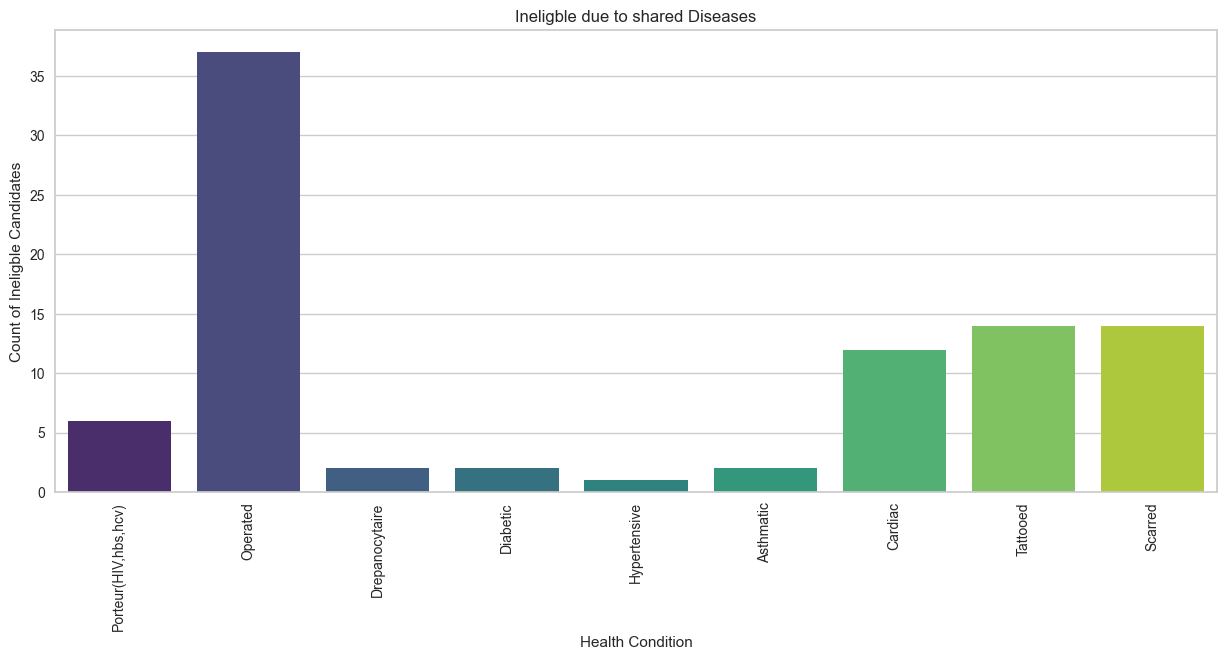

In [322]:
# Count occurrences of 'Yes' in each column of shared_health_columns
non_eligible_count = (not_eligible[shared_health_columns] == 'Yes').sum()

# Display the count of 'Yes' responses per column
display(non_eligible_count)
plt.figure(figsize=(15, 6))
# Create a bar plot
sns.barplot(x=non_eligible_count.index, y=non_eligible_count.values,palette='viridis')
plt.title('Ineligble due to shared Diseases')
plt.xlabel('Health Condition')
plt.ylabel('Count of Ineligble Candidates')
plt.xticks(rotation=90)
plt.show()

Clustering of demographic data

In [323]:
demographic_colmns  = ['Age', 'Education Level', 'Gender', 'Height', 'Weight', 'Marital Status', 'Profession', 'Area of residence', 'Neighborhood of residence', 'Nationality']

In [324]:
donor_year=2019
candidate_donor['Age']=donor_year-candidate_donor['Date of Birth'].dt.year
candidate_donor['Age'].isnull().sum()


np.int64(0)

In [325]:
eligble_candidates=candidate_donor[candidate_donor['Eligibility To Donate']=='Eligible']
eligble_candidates.head()

,Date of Donor Registation,Date of Birth,Education Level,Gender,Height,Weight,Marital Status,Profession,Area of residence,Neighborhood of residence,...,Operated,Drepanocytaire,Diabetic,Hypertensive,Asthmatic,Cardiac,Tattooed,Scarred,Other reason,Age
0,2019-08-06,1999-09-01,Pas Précisé,Homme,172.0,75.0,Célibataire,Chaudronnier,DOUALA,Logbaba,...,No,No,No,No,No,No,No,No,No,20
1,2019-08-06,1978-02-04,Universitaire,Homme,172.0,75.0,Marié (e),Secrétaire comptable,NON PRECISÉ,NDOGPASSI 2,...,No,No,No,No,No,No,No,No,No,41
2,1977-12-25,1977-12-25,Secondaire,Femme,172.0,75.0,Marié (e),Commerçant (e),NON PRECISÉ,Dakar,...,No,No,No,No,No,No,No,No,No,42
3,1986-02-06,1986-02-06,Secondaire,Homme,172.0,75.0,Célibataire,Homme d’affaire,DOUALA,NGANGUE,...,No,No,No,No,No,No,No,No,No,33
4,1988-05-20,1988-05-20,Pas Précisé,Homme,172.0,75.0,Célibataire,Beat Maker,NON PRECISÉ,Douala,...,No,No,No,No,No,No,No,No,No,31


In [326]:
eligble_candidates['Eligibility To Donate'].unique()

array(['Eligible'], dtype=object)

In [327]:
# Convert categorical columns using Label Encoding
categorical_columns = ['Education Level', 'Gender', 'Marital Status', 'Profession',
                       'Area of residence', 'Neighborhood of residence', 'Nationality']
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    eligble_candidates[col] = le.fit_transform(eligble_candidates[col])
    label_encoders[col] = le

In [328]:

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(eligble_candidates[demographic_colmns])


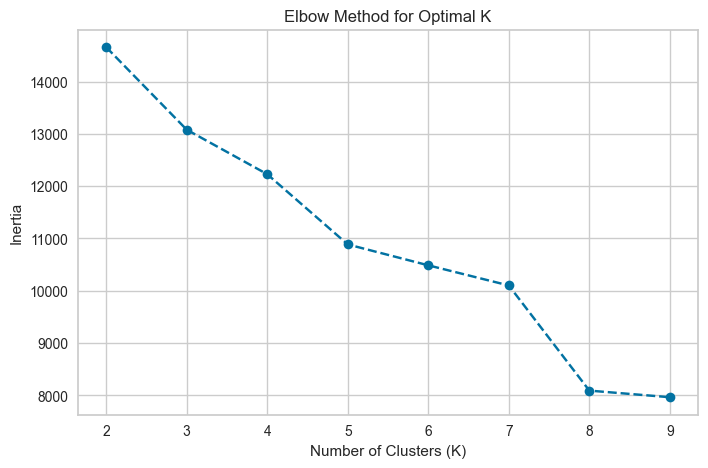

In [329]:
# Find the optimal number of clusters using the Elbow Method
inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()


In [330]:
# Apply K-Means with the chosen number of clusters
k = 8
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
# Add the cluster labels to the original dataset
eligble_candidates['Cluster'] = clusters
eligble_candidates

,Date of Donor Registation,Date of Birth,Education Level,Gender,Height,Weight,Marital Status,Profession,Area of residence,Neighborhood of residence,...,Drepanocytaire,Diabetic,Hypertensive,Asthmatic,Cardiac,Tattooed,Scarred,Other reason,Age,Cluster
0,2019-08-06,1999-09-01,1,1,172.0,75.0,0,101,4,220,...,No,No,No,No,No,No,No,No,20,3
1,2019-08-06,1978-02-04,4,1,172.0,75.0,2,355,12,256,...,No,No,No,No,No,No,No,No,41,0
2,1977-12-25,1977-12-25,3,0,172.0,75.0,2,120,12,154,...,No,No,No,No,No,No,No,No,42,5
3,1986-02-06,1986-02-06,3,1,172.0,75.0,0,208,4,268,...,No,No,No,No,No,No,No,No,33,6
4,1988-05-20,1988-05-20,1,1,172.0,75.0,0,67,12,162,...,No,No,No,No,No,No,No,No,31,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1646,2019-06-27,1978-03-14,3,1,172.0,75.0,0,323,12,103,...,No,No,No,No,No,No,No,No,41,4
1647,2019-06-27,1982-01-02,3,1,172.0,75.0,0,323,12,103,...,No,No,No,No,No,No,No,No,37,4
1648,2019-06-28,1994-09-11,3,1,172.0,75.0,0,379,12,302,...,No,No,No,No,No,No,No,No,25,4
1649,2019-06-28,1989-01-05,2,1,172.0,75.0,0,349,12,305,...,No,No,No,No,No,No,No,No,30,4


In [331]:
# Get cluster-wise numeric feature means
cluster_numeric_means = eligble_candidates.groupby('Cluster')[['Age', 'Height', 'Weight']].mean()
print("Cluster Numeric Feature Means:\n", cluster_numeric_means)


Cluster Numeric Feature Means:
                Age      Height     Weight
Cluster                                  
0        38.760638  172.037234  75.047872
1        27.764526  172.021407  74.948012
2        28.250000  172.000000  75.000000
3        30.021505  171.978495  74.827957
4        28.159483  172.030172  74.844828
5        30.757282  171.864078  74.728155
6        27.738636  171.988636  74.821023
7        31.727273  177.272727  90.909091


In [332]:
# Get the most common category in each cluster
cluster_categorical_modes = eligble_candidates.groupby('Cluster')[categorical_columns].agg(lambda x: x.mode()[0])
cluster_categorical_modes


,Education Level,Gender,Marital Status,Profession,Area of residence,Neighborhood of residence,Nationality
Cluster,,,,,,,
0,3,1,2,120,12,162,1
1,4,1,0,185,12,162,1
2,1,1,2,120,12,162,4
3,1,1,0,349,4,162,1
4,3,1,0,349,12,162,1
5,4,0,0,185,4,162,1
6,3,1,0,185,4,219,1
7,1,1,0,185,12,347,1


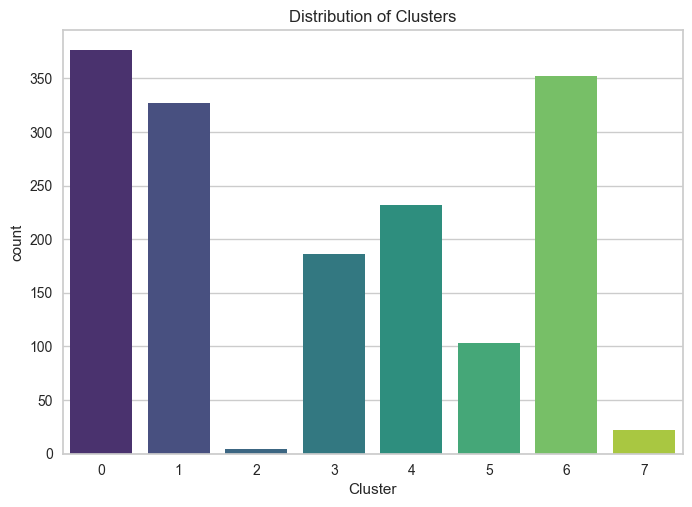

In [333]:
# Barplot of cluster sizes
sns.countplot(x='Cluster', data=eligble_candidates, palette='viridis')
plt.title("Distribution of Clusters")
plt.show()


In [334]:
eligble_candidates.columns


Index(['Date of Donor Registation', 'Date of Birth', 'Education Level',
       'Gender', 'Height', 'Weight', 'Marital Status', 'Profession',
       'Area of residence', 'Neighborhood of residence', 'Nationality',
       'Religion', 'Have you donated blood before?', 'Date of last donation',
       'Hemoglobin', 'Eligibility To Donate', 'Unavailable_Antibiotherapy',
       'Unavailable_Low_Hemoglobin', 'Unavailable_Recent_Donation',
       'Unavailable_Recent_IST', 'Last_Menstrual_Period',
       'Unavailable_Bad_DDR', 'Unavailable_Breastfeeding',
       'Unavailable_Recent_Childbirth', 'Unavailable_Recent_Miscarriage',
       'Unavailable_Pregnant', 'Other_Reasons', 'Confirm_Submission',
       'Transfused less than 3 months ago', 'Porteur(HIV,hbs,hcv)', 'Operated',
       'Drepanocytaire', 'Diabetic', 'Hypertensive', 'Asthmatic', 'Cardiac',
       'Tattooed', 'Scarred', 'Other reason', 'Age', 'Cluster'],
      dtype='object')

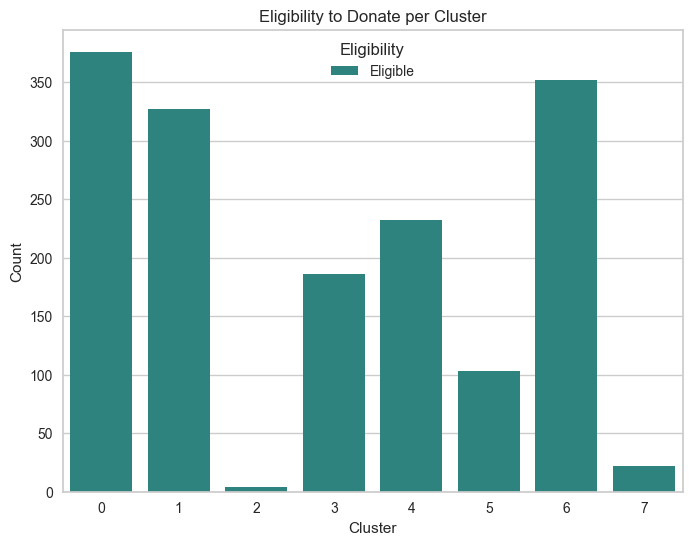

In [335]:


plt.figure(figsize=(8,6))
sns.countplot(x=eligble_candidates['Cluster'], hue=eligble_candidates['Eligibility To Donate'], palette='viridis')

plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Eligibility to Donate per Cluster')
plt.legend(title='Eligibility')
plt.show()




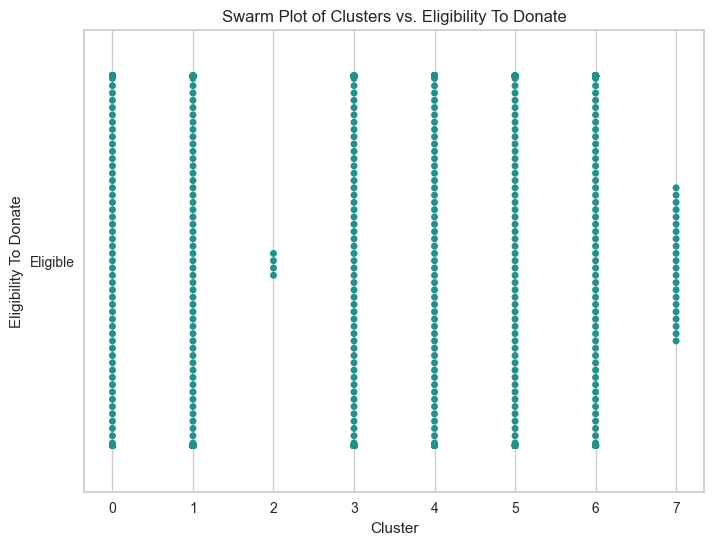

In [336]:
plt.figure(figsize=(8,6))
sns.swarmplot(x=eligble_candidates['Cluster'], y=eligble_candidates['Eligibility To Donate'], palette='viridis')

plt.xlabel('Cluster')
plt.ylabel('Eligibility To Donate')
plt.title('Swarm Plot of Clusters vs. Eligibility To Donate')
plt.show()


Time Series of Last Donation

In [337]:
# Convert date columns to date
candidate_donor['Date of last donation'] = pd.to_datetime(candidate_donor['Date of last donation'], errors='coerce')
candidate_donor['Donation Year'] = candidate_donor['Date of last donation'].dt.year
candidate_donor['Donation Month'] = candidate_donor['Date of last donation'].dt.month
candidate_donor['Donation Month Name'] = candidate_donor['Date of last donation'].dt.strftime('%B')
candidate_donor['Donation Date'] = candidate_donor['Date of last donation'].dt.day
candidate_donor.head(2)


,Date of Donor Registation,Date of Birth,Education Level,Gender,Height,Weight,Marital Status,Profession,Area of residence,Neighborhood of residence,...,Asthmatic,Cardiac,Tattooed,Scarred,Other reason,Age,Donation Year,Donation Month,Donation Month Name,Donation Date
0,2019-08-06,1999-09-01,Pas Précisé,Homme,172.0,75.0,Célibataire,Chaudronnier,DOUALA,Logbaba,...,No,No,No,No,No,20,2017.0,1.0,January,1.0
1,2019-08-06,1978-02-04,Universitaire,Homme,172.0,75.0,Marié (e),Secrétaire comptable,NON PRECISÉ,NDOGPASSI 2,...,No,No,No,No,No,41,2019.0,2.0,February,26.0


In [338]:
# Convert date columns to date('Date of Donor Registation')
candidate_donor['Date of Donor Registation'] = pd.to_datetime(candidate_donor['Date of Donor Registation'], errors='coerce')
candidate_donor['Donation Year 2019'] = candidate_donor['Date of Donor Registation'].dt.year
candidate_donor['Donation Month 2019'] = candidate_donor['Date of Donor Registation'].dt.month
candidate_donor['Donation Month Name 2019'] = candidate_donor['Date of Donor Registation'].dt.strftime('%B')
candidate_donor['Donation Date 2019'] = candidate_donor['Date of Donor Registation'].dt.day
candidate_donor.head(2)

,Date of Donor Registation,Date of Birth,Education Level,Gender,Height,Weight,Marital Status,Profession,Area of residence,Neighborhood of residence,...,Other reason,Age,Donation Year,Donation Month,Donation Month Name,Donation Date,Donation Year 2019,Donation Month 2019,Donation Month Name 2019,Donation Date 2019
0,2019-08-06,1999-09-01,Pas Précisé,Homme,172.0,75.0,Célibataire,Chaudronnier,DOUALA,Logbaba,...,No,20,2017.0,1.0,January,1.0,2019,8,August,6
1,2019-08-06,1978-02-04,Universitaire,Homme,172.0,75.0,Marié (e),Secrétaire comptable,NON PRECISÉ,NDOGPASSI 2,...,No,41,2019.0,2.0,February,26.0,2019,8,August,6


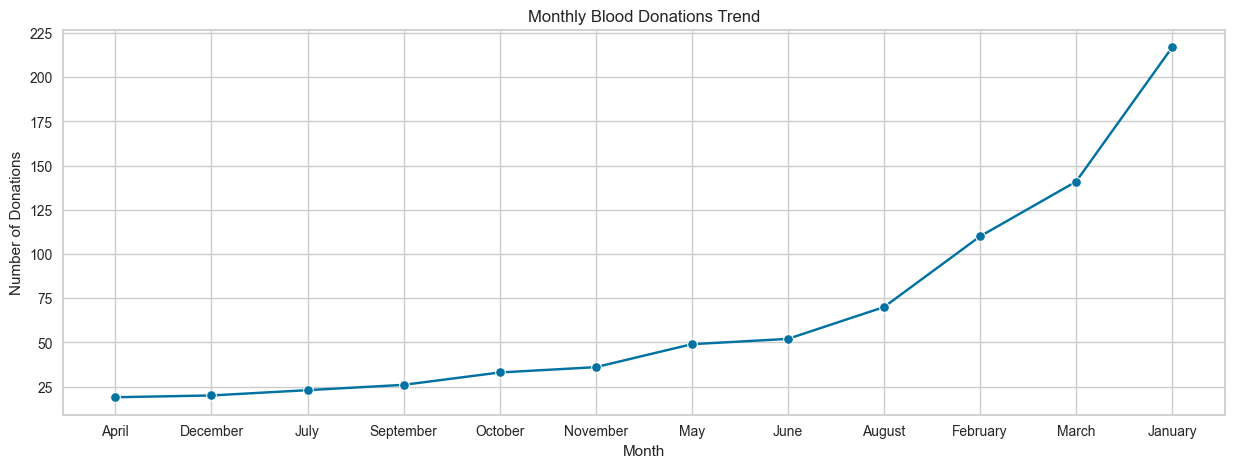

In [339]:
# Aggregate by month to find trends
monthly_donations = candidate_donor.groupby('Donation Month Name').size()
monthly_donations = monthly_donations.sort_values()
# Plotting the monthly donation trends
plt.figure(figsize=(15,5))
sns.lineplot(x=monthly_donations.index, y=monthly_donations.values, marker='o', palette='virdis')
plt.xlabel("Month")
plt.ylabel("Number of Donations")
plt.title("Monthly Blood Donations Trend")
plt.show()


The past Donations were highest in January and lowest in April

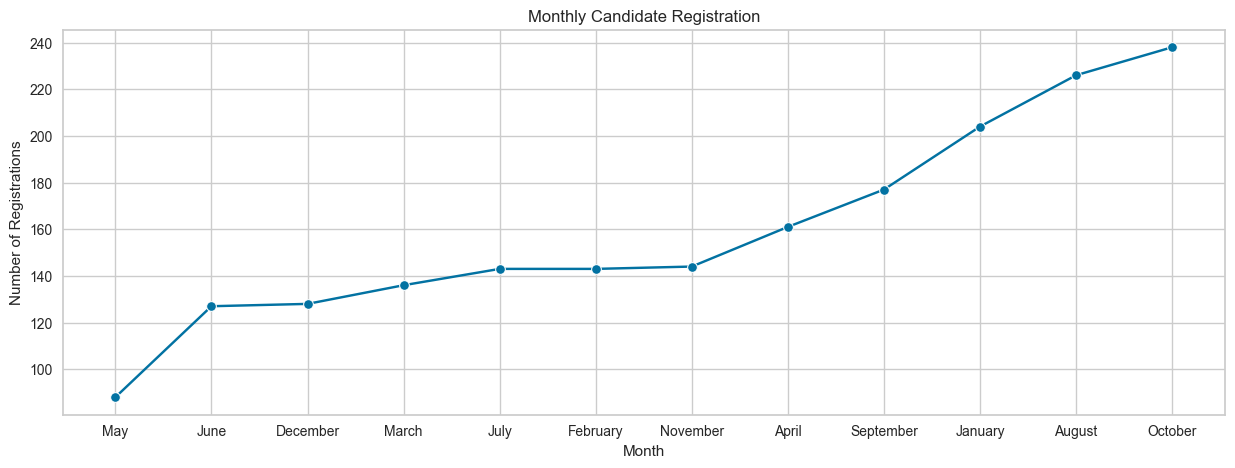

In [340]:
# Aggregate by month to find trends-2019
monthly_donations_2019 = candidate_donor.groupby('Donation Month Name 2019').size()
monthly_donations_2019 = monthly_donations_2019.sort_values()
# Plotting the monthly donation trends
plt.figure(figsize=(15,5))
sns.lineplot(x=monthly_donations_2019.index, y=monthly_donations_2019.values, marker='o', palette='virdis')
plt.xlabel("Month")
plt.ylabel("Number of Registrations")
plt.title("Monthly Candidate Registration")
plt.show()

In [341]:
candidate_donor.columns

Index(['Date of Donor Registation', 'Date of Birth', 'Education Level',
       'Gender', 'Height', 'Weight', 'Marital Status', 'Profession',
       'Area of residence', 'Neighborhood of residence', 'Nationality',
       'Religion', 'Have you donated blood before?', 'Date of last donation',
       'Hemoglobin', 'Eligibility To Donate', 'Unavailable_Antibiotherapy',
       'Unavailable_Low_Hemoglobin', 'Unavailable_Recent_Donation',
       'Unavailable_Recent_IST', 'Last_Menstrual_Period',
       'Unavailable_Bad_DDR', 'Unavailable_Breastfeeding',
       'Unavailable_Recent_Childbirth', 'Unavailable_Recent_Miscarriage',
       'Unavailable_Pregnant', 'Other_Reasons', 'Confirm_Submission',
       'Transfused less than 3 months ago', 'Porteur(HIV,hbs,hcv)', 'Operated',
       'Drepanocytaire', 'Diabetic', 'Hypertensive', 'Asthmatic', 'Cardiac',
       'Tattooed', 'Scarred', 'Other reason', 'Age', 'Donation Year',
       'Donation Month', 'Donation Month Name', 'Donation Date',
       'Dona

In [342]:
candidate_donor['Have you donated blood before?'].unique()

array(['Yes', 'Non'], dtype=object)

In [343]:
donated_before=candidate_donor[candidate_donor['Have you donated blood before?']=='Yes']
donated_before.head(2)

,Date of Donor Registation,Date of Birth,Education Level,Gender,Height,Weight,Marital Status,Profession,Area of residence,Neighborhood of residence,...,Other reason,Age,Donation Year,Donation Month,Donation Month Name,Donation Date,Donation Year 2019,Donation Month 2019,Donation Month Name 2019,Donation Date 2019
0,2019-08-06,1999-09-01,Pas Précisé,Homme,172.0,75.0,Célibataire,Chaudronnier,DOUALA,Logbaba,...,No,20,2017.0,1.0,January,1.0,2019,8,August,6
1,2019-08-06,1978-02-04,Universitaire,Homme,172.0,75.0,Marié (e),Secrétaire comptable,NON PRECISÉ,NDOGPASSI 2,...,No,41,2019.0,2.0,February,26.0,2019,8,August,6


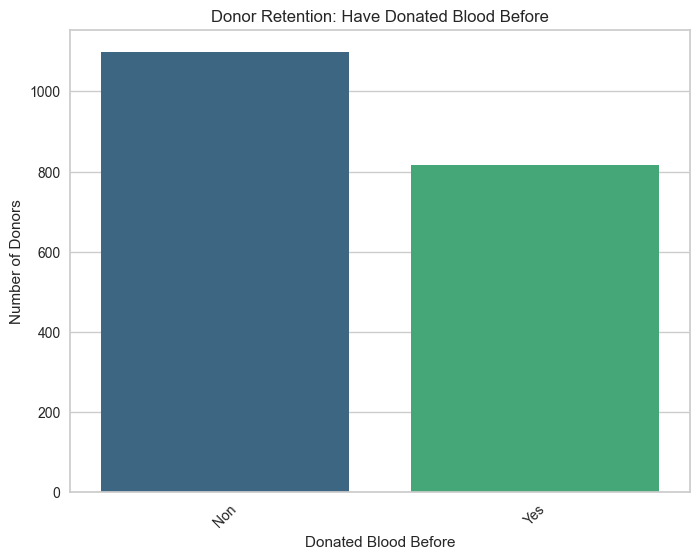

In [344]:
donor_retention=candidate_donor.groupby('Have you donated blood before?').size()
plt.figure(figsize=(8, 6))
sns.barplot(x=donor_retention.index, y=donor_retention.values, palette='viridis')
plt.title("Donor Retention: Have Donated Blood Before")
plt.xlabel("Donated Blood Before")
plt.ylabel("Number of Donors")
plt.xticks(rotation=45)
plt.show()

,Age,Height,Weight
Age,1.000000,0.020539,0.064638
Height,0.020539,1.000000,0.058872
Weight,0.064638,0.058872,1.000000


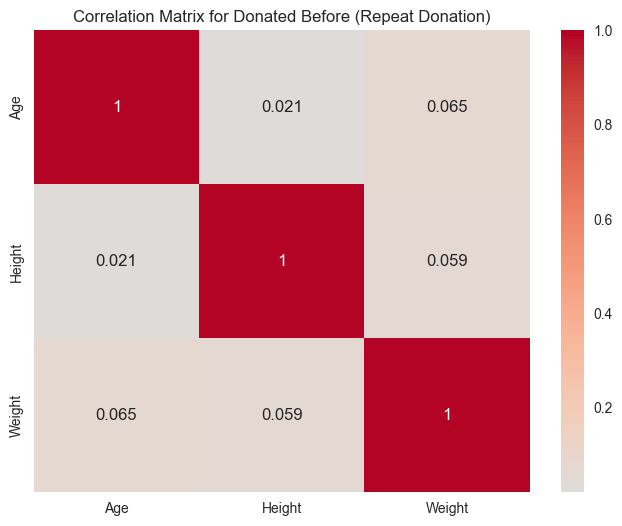

In [345]:
# Select numeric columns for correlation analysis
numeric_cols = ['Age', 'Height', 'Weight']  # Add more numeric columns as needed
donated_corr_matrix = donated_before[numeric_cols].corr()

# Display the correlation matrix
display(donated_corr_matrix)

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(donated_corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix for Donated Before (Repeat Donation)")
plt.show()


In [346]:
for col in demographic_colmns:
  contingency_table_profession = pd.crosstab(donated_before[col], donated_before['Have you donated blood before?'])
  chi2_prof, p_prof, dof, expected = chi2_contingency(contingency_table_profession)
  print(f"Chi-square statistic for {col}: {chi2_prof}")
  print(f"P-value for {col}: {p_prof}")
  # If the p-value is less than 0.05, it suggests a significant relationship
  if p_prof < 0.05:
      print(f"There is a significant relationship between {col} and Repeat Donor")
  else:
      print(f"There is no significant relationship between {col} and Repeat Donor")
  print('\n')

Chi-square statistic for Age: 0.0
P-value for Age: 1.0
There is no significant relationship between Age and Repeat Donor


Chi-square statistic for Education Level: 0.0
P-value for Education Level: 1.0
There is no significant relationship between Education Level and Repeat Donor


Chi-square statistic for Gender: 0.0
P-value for Gender: 1.0
There is no significant relationship between Gender and Repeat Donor


Chi-square statistic for Height: 0.0
P-value for Height: 1.0
There is no significant relationship between Height and Repeat Donor


Chi-square statistic for Weight: 0.0
P-value for Weight: 1.0
There is no significant relationship between Weight and Repeat Donor


Chi-square statistic for Marital Status: 0.0
P-value for Marital Status: 1.0
There is no significant relationship between Marital Status and Repeat Donor


Chi-square statistic for Profession: 0.0
P-value for Profession: 1.0
There is no significant relationship between Profession and Repeat Donor


Chi-square statistic f

Predicting based on past data

In [347]:
columns_to_select = ['Date of Donor Registation', 'Education Level', 'Gender', 'Height', 'Weight',
    'Marital Status', 'Profession', 'Area of residence', 'Neighborhood of residence', 'Nationality',
    'Religion', 'Have you donated blood before?', 'Date of last donation', 'Hemoglobin', 'Eligibility To Donate',
    'Unavailable_Antibiotherapy', 'Unavailable_Low_Hemoglobin', 'Unavailable_Recent_Donation',
    'Unavailable_Recent_IST', 'Last_Menstrual_Period', 'Unavailable_Bad_DDR', 'Unavailable_Breastfeeding',
    'Unavailable_Recent_Childbirth', 'Unavailable_Recent_Miscarriage', 'Unavailable_Pregnant', 'Other_Reasons',
    'Confirm_Submission', 'Transfused less than 3 months ago', 'Porteur(HIV,hbs,hcv)', 'Operated',
    'Drepanocytaire', 'Diabetic', 'Hypertensive', 'Asthmatic', 'Cardiac', 'Tattooed', 'Scarred', 'Other reason',
    'Age']

# Select only the columns specified
eligible_data = candidate_donor[columns_to_select]
eligible_data['Days Since Last Period'] = (eligible_data['Date of Donor Registation'] - eligible_data['Last_Menstrual_Period']).dt.days
eligible_data['Days Since Last Donation'] = (eligible_data['Date of Donor Registation'] - eligible_data['Date of last donation']).dt.days

In [348]:
eligible_data=eligible_data.drop(columns=['Date of Donor Registation','Date of last donation','Last_Menstrual_Period'])
eligible_data.columns

Index(['Education Level', 'Gender', 'Height', 'Weight', 'Marital Status',
       'Profession', 'Area of residence', 'Neighborhood of residence',
       'Nationality', 'Religion', 'Have you donated blood before?',
       'Hemoglobin', 'Eligibility To Donate', 'Unavailable_Antibiotherapy',
       'Unavailable_Low_Hemoglobin', 'Unavailable_Recent_Donation',
       'Unavailable_Recent_IST', 'Unavailable_Bad_DDR',
       'Unavailable_Breastfeeding', 'Unavailable_Recent_Childbirth',
       'Unavailable_Recent_Miscarriage', 'Unavailable_Pregnant',
       'Other_Reasons', 'Confirm_Submission',
       'Transfused less than 3 months ago', 'Porteur(HIV,hbs,hcv)', 'Operated',
       'Drepanocytaire', 'Diabetic', 'Hypertensive', 'Asthmatic', 'Cardiac',
       'Tattooed', 'Scarred', 'Other reason', 'Age', 'Days Since Last Period',
       'Days Since Last Donation'],
      dtype='object')

In [349]:
eligible_data['Days Since Last Donation']=eligible_data['Days Since Last Donation'].fillna(0)

In [350]:
eligible_data.to_csv('eligible_data.csv',index=False)

In [351]:

# Identify categorical columns with dtype 'object' or 'category' excluding datetime columns
categorical_columns = eligible_data.select_dtypes(include=['object']).columns
categorical_columns = [col for col in categorical_columns]
label_encoders = {}

# Iterate over each categorical column and apply Label Encoding
for col in categorical_columns:
    le = LabelEncoder()
    eligible_data[col]=eligible_data[col].astype(str)
    label_encoders[col] = le

eligible_data[categorical_columns].head()


,Education Level,Gender,Marital Status,Profession,Area of residence,Neighborhood of residence,Nationality,Religion,Have you donated blood before?,Eligibility To Donate,...,"Porteur(HIV,hbs,hcv)",Operated,Drepanocytaire,Diabetic,Hypertensive,Asthmatic,Cardiac,Tattooed,Scarred,Other reason
0,Pas Précisé,Homme,Célibataire,Chaudronnier,DOUALA,Logbaba,CAMEROUNAISE,Pas Précisé,Yes,Eligible,...,No,No,No,No,No,No,No,No,No,No
1,Universitaire,Homme,Marié (e),Secrétaire comptable,NON PRECISÉ,NDOGPASSI 2,CAMEROUNAISE,Chretien (Ne de nouveau),Yes,Eligible,...,No,No,No,No,No,No,No,No,No,No
2,Secondaire,Femme,Marié (e),Commerçant (e),NON PRECISÉ,Dakar,CAMEROUNAISE,Chretien (Catholique),Yes,Eligible,...,No,No,No,No,No,No,No,No,No,No
3,Secondaire,Homme,Célibataire,Homme d’affaire,DOUALA,NGANGUE,CAMEROUNAISE,Pas Précisé,Non,Eligible,...,No,No,No,No,No,No,No,No,No,No
4,Pas Précisé,Homme,Célibataire,Beat Maker,NON PRECISÉ,Douala,CAMEROUNAISE,Chretien (Catholique),Non,Eligible,...,No,No,No,No,No,No,No,No,No,No


In [352]:
numerical_columns = ['Height', 'Weight', 'Age', 'Days Since Last Period', 'Days Since Last Donation', 'Hemoglobin']

# Initialize label encoders and imputer
label_encoders = {}

# Encoding categorical columns
for col in categorical_columns:
    le = LabelEncoder()
    eligible_data[col] = le.fit_transform(eligible_data[col].astype(str))
    label_encoders[col] = le

    # If the column is "Eligible to Donate", print the mapping
    if col == "Eligibility To Donate":
        print(f"Mapping for column '{col}':")
        for i, label in enumerate(le.classes_):
            print(f"{i}: {label}")
        print("\n")
# Scaling numerical columns



Mapping for column 'Eligibility To Donate':
0: Définitivement non-eligible
1: Eligible
2: Temporairement Non-eligible




In [353]:
eligible_data[numerical_columns] = scaler.fit_transform(eligible_data[numerical_columns])


In [354]:
eligible_data.isnull().sum()


Education Level                      0
Gender                               0
Height                               0
Weight                               0
Marital Status                       0
Profession                           0
Area of residence                    0
Neighborhood of residence            0
Nationality                          0
Religion                             0
Have you donated blood before?       0
Hemoglobin                           0
Eligibility To Donate                0
Unavailable_Antibiotherapy           0
Unavailable_Low_Hemoglobin           0
Unavailable_Recent_Donation          0
Unavailable_Recent_IST               0
Unavailable_Bad_DDR                  0
Unavailable_Breastfeeding            0
Unavailable_Recent_Childbirth        0
Unavailable_Recent_Miscarriage       0
Unavailable_Pregnant                 0
Other_Reasons                        0
Confirm_Submission                   0
Transfused less than 3 months ago    0
Porteur(HIV,hbs,hcv)     

In [355]:
X = eligible_data.drop('Eligibility To Donate', axis=1)
y = eligible_data['Eligibility To Donate']
X=X.drop(columns=['Confirm_Submission'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Best Feature Subset: Index(['Nationality', 'Hemoglobin', 'Unavailable_Antibiotherapy',
       'Unavailable_Low_Hemoglobin', 'Unavailable_Recent_Donation',
       'Unavailable_Recent_IST', 'Transfused less than 3 months ago',
       'Operated', 'Diabetic', 'Hypertensive', 'Asthmatic', 'Cardiac',
       'Tattooed'],
      dtype='object')


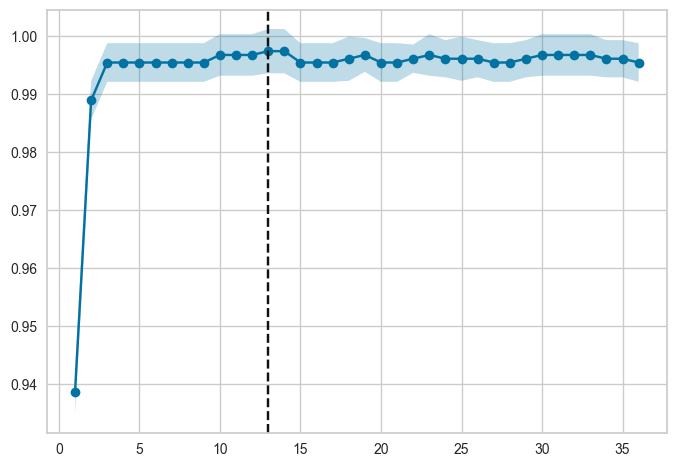

In [356]:
# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5)

# Perform RFECV to find the best feature subset
rfecv = RFECV(estimator=model, step=1, cv=cv, scoring='accuracy')
rfecv.fit(X_train, y_train)
# Get selected features
selected_features = X_train.columns[rfecv.support_]
print("Best Feature Subset:", selected_features)

In [357]:
# Train model using the best subset
X_selected_train = X_train
model.fit(X_selected_train, y_train)
# Check model performance on the test data
test_accuracy = model.score(X_test, y_test)

print("Model Accuracy on Test Data:", test_accuracy)


Model Accuracy on Test Data: 0.9947780678851175


In [358]:
'''cv = StratifiedKFold(5)
visualizer = RFECV(RandomForestClassifier(), cv=cv, scoring='f1_weighted')

visualizer.fit(X_train, y_train)
visualizer.show()           '''

"cv = StratifiedKFold(5)\nvisualizer = RFECV(RandomForestClassifier(), cv=cv, scoring='f1_weighted')\n\nvisualizer.fit(X_train, y_train)\nvisualizer.show()           "

In [359]:
# Save the trained model and preprocessing objects
joblib.dump(model, 'blood_donation_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

['label_encoders.pkl']

In [360]:
# Sample data generation
num_rows = 100
data = {
    'Education Level': np.random.choice(candidate_donor['Education Level'], size=num_rows),
    'Gender': np.random.choice(candidate_donor['Gender'], size=num_rows),
    'Height': np.random.randint(150, 190, size=num_rows),
    'Weight': np.random.randint(50, 100, size=num_rows),
    'Marital Status': np.random.choice(candidate_donor['Marital Status'], size=num_rows),
    'Profession': np.random.choice(candidate_donor['Profession'], size=num_rows),
    'Area of residence': np.random.choice(candidate_donor['Area of residence'], size=num_rows),
    'Neighborhood of residence': np.random.choice(candidate_donor['Neighborhood of residence'], size=num_rows),
    'Nationality': np.random.choice(candidate_donor['Nationality'], size=num_rows),
    'Religion': np.random.choice(candidate_donor['Religion'], size=num_rows),
    'Have you donated blood before?': np.random.choice(['Yes', 'No'], size=num_rows),
    'Hemoglobin': np.random.uniform(12, 18, size=num_rows),
    'Unavailable_Antibiotherapy': np.random.choice(['Yes', 'No'], size=num_rows),
    'Unavailable_Low_Hemoglobin': np.random.choice(['Yes', 'No'], size=num_rows),
    'Unavailable_Recent_Donation': np.random.choice(['Yes', 'No'], size=num_rows),
    'Unavailable_Recent_IST': np.random.choice(['Yes', 'No'], size=num_rows),
    'Unavailable_Bad_DDR': np.random.choice(['Yes', 'No'], size=num_rows),
    'Unavailable_Breastfeeding': np.random.choice(['Yes', 'No'], size=num_rows),
    'Unavailable_Recent_Childbirth': np.random.choice(['Yes', 'No'], size=num_rows),
    'Unavailable_Recent_Miscarriage': np.random.choice(['Yes', 'No'], size=num_rows),
    'Unavailable_Pregnant': np.random.choice(['Yes', 'No'], size=num_rows),
    'Other_Reasons': np.random.choice(['Yes', 'No'], size=num_rows),
    'Transfused less than 3 months ago': np.random.choice(['Yes', 'No'], size=num_rows),
    'Porteur(HIV,hbs,hcv)': np.random.choice(['Yes', 'No'], size=num_rows),
    'Operated': np.random.choice(['Yes', 'No'], size=num_rows),
    'Drepanocytaire': np.random.choice(['Yes', 'No'], size=num_rows),
    'Diabetic': np.random.choice(['Yes', 'No'], size=num_rows),
    'Hypertensive': np.random.choice(['Yes', 'No'], size=num_rows),
    'Asthmatic': np.random.choice(['Yes', 'No'], size=num_rows),
    'Cardiac': np.random.choice(['Yes', 'No'], size=num_rows),
    'Tattooed': np.random.choice(['Yes', 'No'], size=num_rows),
    'Scarred': np.random.choice(['Yes', 'No'], size=num_rows),
    'Other reason': np.random.choice(['Yes', 'No'], size=num_rows),
    'Age': np.random.randint(18, 65, size=num_rows),
    'Days Since Last Period': np.random.randint(0, 30, size=num_rows),
    'Days Since Last Donation': np.random.randint(0, 180, size=num_rows)
}

df = pd.DataFrame(data)
df.to_csv('sampletest_data.csv', index=False)

In [361]:
candidate_donor['Eligibility To Donate'].unique()

array(['Eligible', 'Temporairement Non-eligible',
       'Définitivement non-eligible'], dtype=object)